# Створення нейронної мережі

У цьому завданні ми створимо повнозв'язну нейронну мережу, використовуючи при цьому низькорівневі механізми tensorflow.

Архітектура нейромережі представлена на наступному малюнку. Як бачиш, у ній є один вхідний шар, два приховані, а також вихідний шар. В якості активаційної функції у прихованих шарах буде використовуватись сигмоїда. На вихідному шарі ми використовуємо softmax.

Частина коду зі створення мережі вже написана, тобі потрібно заповнити пропуски у вказаних місцях.

## Архітектура нейронної мережі

<img src="http://cs231n.github.io/assets/nn1/neural_net2.jpeg" alt="nn" style="width: 400px;"/>


## Про датасет MNIST

Дану нейромережу ми будемо вивчати на датасеті MNIST. Цей датасет являє собою велику кількість зображень рукописних цифр розміром $28 \times 28$ пікселів. Кожен піксель приймає значення від 0 до 255.

Як і раніше, датасет буде розділений на навчальну та тестову вибірки. При цьому ми виконаємо нормалізацію всіх зображень, щоб значення пікселів знаходилось у проміжку від 0 до 1, розділивши яскравість кожного пікселя на 255.

Окрім того, архітектура нейронної мережі очікує на вхід вектор. У нашому ж випадку кожен об'єкт вибірки являє собою матрицю. Що ж робити? У цьому завданні ми "розтягнемо" матрицю $28 \times 28$, отримавши при цьому вектор, що складається з 784 елементів.

![MNIST Dataset](https://www.researchgate.net/profile/Steven-Young-5/publication/306056875/figure/fig1/AS:393921575309346@1470929630835/Example-images-from-the-MNIST-dataset.png)

Більше інформації про датасет можна знайти [тут](http://yann.lecun.com/exdb/mnist/).

In [3]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import keras as K
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [4]:
num_classes = 10 # загальна кількість класів, у нашому випадку це цифри від 0 до 9
num_features = 784 # кількість атрибутів вхідного вектора 28 * 28 = 784

learning_rate = 0.001 # швидкість навчання нейронної мережі
training_steps = 3000 # максимальне число епох
batch_size = 256 # перераховувати ваги мережі ми будемо не на всій вибірці, а на її випадковій підмножині з batch_size елементів
display_step = 100 # кожні 100 ітерацій ми будемо показувати поточне значення функції втрат і точності

n_hidden_1 = 128 # кількість нейронів 1-го шару
n_hidden_2 = 256 # кількість нейронів 2-го шару

In [5]:
# from tensorflow.keras.datasets import mnist
from keras.datasets import mnist

# Завантажуємо датасет
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Перетворюємо цілочисельні пікселі на тип float32
x_train, x_test = np.array(x_train, np.float32), np.array(x_test, np.float32)

# Перетворюємо матриці розміром 28x28 пікселів у вектор з 784 елементів
x_train, x_test = x_train.reshape([-1, num_features]), x_test.reshape([-1, num_features])

# Нормалізуємо значення пікселів
x_train, x_test = x_train / 255., x_test / 255.

# Перемішаємо тренувальні дані
train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_data = train_data.repeat().shuffle(5000).batch(batch_size).prefetch(1)

In [6]:
# Створимо нейронну мережу

class DenseLayer(tf.Module):
    def __init__(self, in_features, out_features, name=None):
        super().__init__(name=name)
        self.w = tf.Variable(
            tf.random.normal([in_features, out_features]), name="w"
        )
        self.b = tf.Variable(tf.zeros([out_features]), name="b")

    def __call__(self, x, activation=0):
        y = tf.matmul(x, self.w) + self.b
        if activation != 0:
            return tf.nn.softmax(y)
        else:
            return tf.nn.sigmoid(y)

class NN(tf.Module):
  def __init__(self, name=None):
    super().__init__(name=name)
    # Перший шар, який складається з 128 нейронів
    self.layer_1 = DenseLayer(in_features=num_features,out_features=n_hidden_1)
    # Місце для вашого коду
    # Другий шар, який складається з 256 нейронів
    self.layer_2 = DenseLayer(in_features=n_hidden_1,out_features=n_hidden_2)
    # Місце для вашого коду
    # Вихідний шар
    self.out_layer = DenseLayer(in_features=n_hidden_2,out_features=num_classes)
    # Місце для вашого коду


  def __call__(self, x):
    # Передача даних через перші два шари та вихідний шар з функцією активації softmax
    x = self.layer_1(x,activation=0)
    x = self.layer_2(x,activation=0)


    return self.out_layer(x,activation=1)

In [7]:
# В якості функції помилки в даному випадку зручно взяти крос-ентропію
def cross_entropy(y_pred, y_true):
    # Закодувати label в one hot vector
    y_true = tf.one_hot(y_true, depth=num_classes)

    # Значення передбачення, щоб уникнути помилки log(0).
    y_pred = tf.clip_by_value(y_pred, 1e-9, 1.)

    # Обчислення крос-ентропії
    return tf.reduce_mean(-tf.reduce_sum(y_true * tf.math.log(y_pred)))

# Як метрику якості використовуємо точність
def accuracy(y_pred, y_true):
    # Місце для вашого коду
    # ...
    correct = tf.equal(tf.argmax(y_pred, axis=1), tf.cast(y_true, tf.int64))
    return tf.reduce_mean(tf.cast(correct, tf.float32))

In [11]:
# Створимо екземпляр нейронної мережі
neural_net = NN(name="mnist")

# Функція навчання нейромережі
def train(neural_net, input_x, output_y):
  # Для налаштування вагів мережі будемо використовувати стохастичний градієнтний спуск
  optimizer = tf.optimizers.SGD(learning_rate)

  # Активація автоматичного диференціювання
  with tf.GradientTape() as g:
    pred = neural_net(input_x)
    loss = cross_entropy(pred, output_y)

    # Отримаємо список оптимізованих параметрів
    best_parameters = neural_net.trainable_variables
    # Місце для вашого коду
    # Обчислимо за ними значення градієнта
    gradients = g.gradient(loss, best_parameters)
    # Місце для вашого коду

    # Модифікуємо параметри
    optimizer.apply_gradients(zip(gradients,best_parameters))

    # Місце для вашого коду

    return loss

In [12]:
# Тренування мережі

loss_history = []  # кожні display_step кроків зберігай в цьому списку поточну помилку нейромережі
accuracy_history = [] # кожні display_step кроків зберігай в цьому списку поточну точність нейромережі

# У цьому циклі ми будемо проводити навчання нейронної мережі
# із тренувального датасета train_data вилучи випадкову підмножину, на якій
# відбудеться тренування. Використовуй метод take, доступний для тренувального датасета.
for step, (batch_x, batch_y) in enumerate(train_data.take(training_steps), 1):
    # Оновлюємо ваги нейронної мережі
    # Місце для вашого коду
    loss = train(neural_net,batch_x,batch_y)
    if step % display_step == 0:
        pred = neural_net(batch_x)
        # Місце для вашого коду
        acc = accuracy(pred,batch_y)
        loss_history.append(loss.numpy())
        accuracy_history.append(acc.numpy())
        print(f"Step {step}, Loss: {loss:.4f}, Accuracy: {acc:.4f}")

Step 100, Loss: 363.1170, Accuracy: 0.6523
Step 200, Loss: 264.0632, Accuracy: 0.7656
Step 300, Loss: 233.2855, Accuracy: 0.7656
Step 400, Loss: 193.9050, Accuracy: 0.8164
Step 500, Loss: 140.3355, Accuracy: 0.8516
Step 600, Loss: 148.4077, Accuracy: 0.8398
Step 700, Loss: 95.7452, Accuracy: 0.8984
Step 800, Loss: 108.1156, Accuracy: 0.8594
Step 900, Loss: 115.8177, Accuracy: 0.8867
Step 1000, Loss: 95.7212, Accuracy: 0.8789
Step 1100, Loss: 95.0377, Accuracy: 0.8867
Step 1200, Loss: 101.9450, Accuracy: 0.8945
Step 1300, Loss: 95.9988, Accuracy: 0.9023
Step 1400, Loss: 86.6875, Accuracy: 0.8984
Step 1500, Loss: 78.8542, Accuracy: 0.9180
Step 1600, Loss: 79.9306, Accuracy: 0.9102
Step 1700, Loss: 89.1985, Accuracy: 0.8828
Step 1800, Loss: 77.9995, Accuracy: 0.9141
Step 1900, Loss: 98.4119, Accuracy: 0.8945
Step 2000, Loss: 72.5483, Accuracy: 0.8984
Step 2100, Loss: 72.8440, Accuracy: 0.9141
Step 2200, Loss: 56.0333, Accuracy: 0.9531
Step 2300, Loss: 73.1771, Accuracy: 0.9336
Step 2400, 

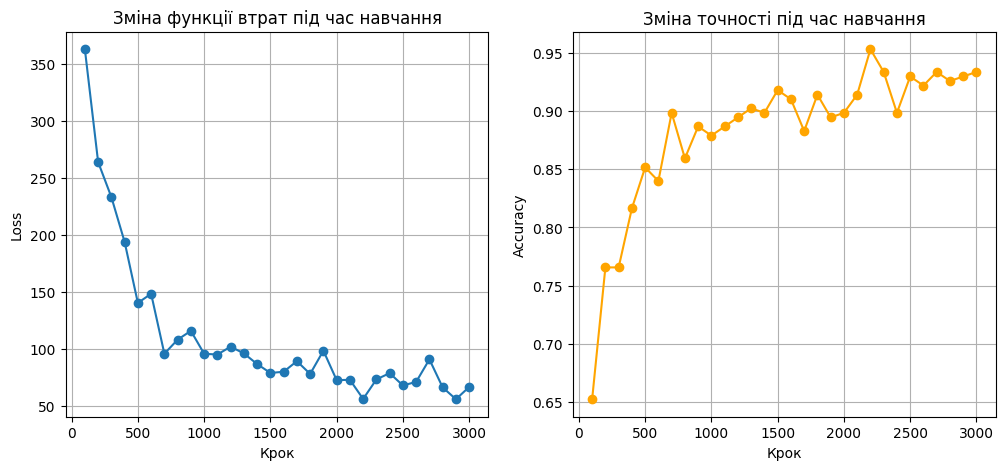

In [13]:
# Виведіть графіки залежності зміни точності і втрат від кроку
# Якщо все зроблено правильно, то точність повинна зростати, а втрати зменшуватись

import matplotlib.pyplot as plt

# Виведіть графік функції втрат
# Місце для вашого коду

# Виведіть графік точності
# Місце для вашого коду

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(display_step, training_steps+1, display_step), loss_history, marker='o')
plt.title("Зміна функції втрат під час навчання")
plt.xlabel("Крок")
plt.ylabel("Loss")
plt.grid(True)

# Графік точності
plt.subplot(1, 2, 2)
plt.plot(range(display_step, training_steps+1, display_step), accuracy_history, marker='o', color='orange')
plt.title("Зміна точності під час навчання")
plt.xlabel("Крок")
plt.ylabel("Accuracy")
plt.grid(True)

plt.show()


In [14]:
# Обчисліть точність навченої нейромережі
# Місце для вашого коду
train_pred = neural_net(x_train)
train_acc = accuracy(train_pred, y_train)
print(f"Train Accuracy: {train_acc.numpy():.4f}")

# Тестування моделі на тестових даних
# Місце для вашого коду
test_pred = neural_net(x_test)
test_acc = accuracy(test_pred, y_test)
print(f"Test Accuracy: {test_acc.numpy():.4f}")

Train Accuracy: 0.9190
Test Accuracy: 0.9060


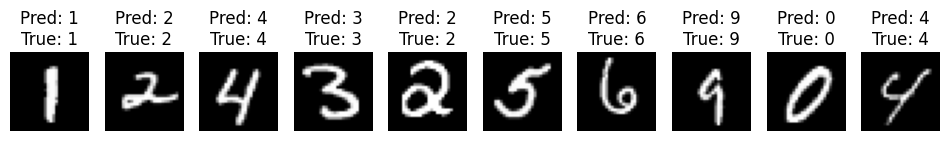

Правильних відповідей: 10/10 (100.0%)


In [20]:
# Протестуйте навчену нейромережу на 10 зображеннях. З тестової вибірки візьміть 10
# випадкових зображень і передайте їх у нейронну мережу.
# Виведіть зображення та випишіть  поруч відповідь нейромережі.
# Зробіть висновок про те, чи помиляється твоя нейронна мережа, і якщо так, то як часто?

# Місце для вашого коду

idx = np.random.choice(len(x_test), 10, replace=False)


sample_images = x_test[idx]
sample_labels = y_test[idx]

predictions = neural_net(sample_images)

predicted_classes = tf.argmax(predictions, axis=1).numpy()

plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(sample_images[i].reshape(28, 28), cmap="gray")
    plt.title(f"Pred: {predicted_classes[i]}\nTrue: {sample_labels[i]}")
    plt.axis("off")
plt.show()

correct = np.sum(predicted_classes == sample_labels)
print(f"Правильних відповідей: {correct}/10 ({correct/10:.1%})")



Під час навчання було досягнуто точність:<br> На навчальній - 91,9%<br> На тестовій - 90,6%<br> Я вважаю що це дуже гарні показники і що відсутнє перенавчання.<br> Під час останнього тестування на окремих 10 зображеннях і навчальна мережа показала 100% результа. Отримані результати показують що дану мережу можна використовувати і на далі.